In [3]:
import copy 
import time
import torch 
from torchvision import  transforms
from torchvision.datasets import FashionMNIST
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
import torch.utils.data as Data 
from model import AlexNet

In [4]:
def train_val_data_process():
  train_data = FashionMNIST(root='./data',
                            train=True,
                            transform= transforms.Compose([transforms.Resize(size=227),transforms.ToTensor()]),
                            download=True)
  
  train_data, Val_data = Data.random_split(train_data, [round(len(train_data)*0.8), round(len(train_data)*0.2)])

  train_dataloader = Data.DataLoader(dataset= train_data,
                                     batch_size = 32,
                                     shuffle = True,
                                     num_workers = 2)
  
  Val_dataloader = Data.DataLoader(dataset= Val_data,
                                     batch_size = 32,
                                     shuffle = True,
                                     num_workers = 2)
  return train_dataloader, Val_dataloader

In [5]:
def train_model_process(model,train_dataloader,val_dataloader,num_epochs):
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 
  optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
  criterion = nn.CrossEntropyLoss()
  model = model.to(device)
  best_model_wts = copy.deepcopy(model.state_dict())

  #初始化参数
  best_acc =0.0
  train_loss_all = []
  val_loss_all = []
  train_acc_all = []
  val_acc_all = []
  since = time.time()

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs - 1))
    print('-' * 10)

    train_loss = 0.0
    train_corrects = 0
    val_loss = 0.0
    val_corrects = 0
    train_num = 0 
    val_num = 0 

    for step, (b_x,b_y) in enumerate(train_dataloader):
      b_x = b_x.to(device)
      b_y = b_y.to(device)
      model.train()

      #前向传播
      output = model(b_x)
      pre_lab = torch.argmax(output,dim=1)
      loss = criterion(output,b_y)

      #梯度初始化为0
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * b_x.size(0)
      train_corrects += torch.sum(pre_lab == b_y.data)
      train_num += b_x.size(0)

    for step, (b_x,b_y) in enumerate(val_dataloader):
      b_x = b_x.to(device)
      b_y = b_y.to(device)
      model.eval()

      #反向传播
      output = model(b_x)
      pre_lab = torch.argmax(output,dim=1)
      loss = criterion(output,b_y)

      #对损失函数累加
      val_loss += loss.item() * b_x.size(0)
      val_corrects += torch.sum(pre_lab == b_y.data)
      val_num += b_x.size(0)



    train_loss_all.append(train_loss / train_num)
    train_acc_all.append(train_corrects.double().item() / train_num)
    val_loss_all.append(val_loss / val_num)
    val_acc_all.append(val_corrects.double().item() / val_num)

    print("{} train loss:{:.4f} train acc: {:.4f}".format(epoch, train_loss_all[-1], train_acc_all[-1]))
    print("{} val loss:{:.4f} val acc: {:.4f}".format(epoch, val_loss_all[-1], val_acc_all[-1]))

    if val_acc_all[-1]>best_acc:
      best_acc = val_acc_all[-1]
      best_model_wts = copy.deepcopy(model.state_dict())

    time_use = time.time() - since
    print('Time use: {:.0f}m {:.0f}s'.format(time_use // 60, time_use % 60))
  
  torch.save(best_model_wts, r".\best_AlexNet.pth")

  train_process = pd.DataFrame(data={"epoch":range(num_epochs),
                                       "train_loss_all":train_loss_all,
                                       "val_loss_all":val_loss_all,
                                       "train_acc_all":train_acc_all,
                                       "val_acc_all":val_acc_all,})
  return train_process

    
 

In [6]:
def matplot_acc_loss(train_process):
    # 显示每一次迭代后的训练集和验证集的损失函数和准确率
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_process['epoch'], train_process.train_loss_all, "ro-", label="Train loss")
    plt.plot(train_process['epoch'], train_process.val_loss_all, "bs-", label="Val loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.subplot(1, 2, 2)
    plt.plot(train_process['epoch'], train_process.train_acc_all, "ro-", label="Train acc")
    plt.plot(train_process['epoch'], train_process.val_acc_all, "bs-", label="Val acc")
    plt.xlabel("epoch")
    plt.ylabel("acc")
    plt.legend()
    plt.show()


100%|██████████| 26.4M/26.4M [00:05<00:00, 4.42MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 79.6kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:05<00:00, 738kB/s] 


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 105kB/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch 0/19
----------
0 train loss:0.5743 train acc: 0.7837
0 val loss:0.3947 val acc: 0.8536
Time use: 1m 18s
Epoch 1/19
----------
1 train loss:0.3597 train acc: 0.8670
1 val loss:0.3690 val acc: 0.8657
Time use: 2m 36s
Epoch 2/19
----------
2 train loss:0.3154 train acc: 0.8827
2 val loss:0.3088 val acc: 0.8854
Time use: 4m 7s
Epoch 3/19
----------
3 train loss:0.2888 train acc: 0.8954
3 val loss:0.3331 val acc: 0.8821
Time use: 5m 32s
Epoch 4/19
----------
4 train loss:0.2760 train acc: 0.8983
4 val loss:0.2932 val acc: 0.8952
Time use: 7m 3s
Epoch 5/19
----------
5 train loss:0.2663 train acc: 0.9028
5 val loss:0.2824 val acc: 0.8991
Time use: 8m 37s
Epoch 6/19
----------
6 train loss:0.2594 train acc: 0.9060
6 val loss:0.2924 val acc: 0.8992
Time use: 10m 10s
Epoch 7/19
----------
7 train loss:0.2488 train acc: 0.9097
7 val loss:0.2956 val acc: 0.8987
Time use: 11m 41s
Epoch 8/19
----------
8

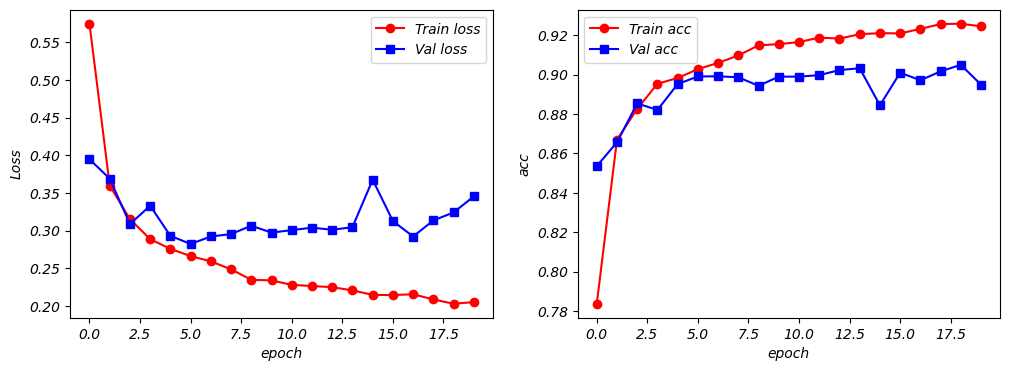

In [7]:
if __name__ == '__main__':
    # 加载需要的模型
    AlexNet= AlexNet()
    # 加载数据集
    train_data, val_data = train_val_data_process()
    # 利用现有的模型进行模型的训练
    train_process = train_model_process(AlexNet, train_data, val_data, num_epochs=20)
    matplot_acc_loss(train_process)

        